# Prostate cancer detection

## Imports

In [ ]:
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, make_scorer, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from tensorflow.keras.applications import MobileNetV2

## Dataset

In [2]:
DATA_DIR = Path.cwd()
IMAGE_DIR = DATA_DIR / "images"
MASK_DIR = DATA_DIR / "masks"
MODEL_DIR = DATA_DIR / "model_artifacts"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 8
RANDOM_STATE = 42
GRADE_COLUMNS = ["NC", "G3", "G4", "G5"]
CLASS_NAMES = ["Non-cancerous", "Cancerous"]

In [3]:
train_df = pd.read_excel(DATA_DIR / "partition" / "Test" / "Train.xlsx")
test_df = pd.read_excel(DATA_DIR / "partition" / "Test" / "Test.xlsx")
wsi_df = pd.read_excel(DATA_DIR / "wsi_labels.xlsx")
train_df.head()

,image_name,NC,G3,G4,G5,G4C
0,16B0001851_Block_Region_1_0_0_xini_6803_yini_5...,0,0,0,1,0
1,16B0001851_Block_Region_1_0_1_xini_7827_yini_5...,0,0,0,1,0
2,16B0001851_Block_Region_1_0_2_xini_8851_yini_5...,0,0,0,1,0
3,16B0001851_Block_Region_1_0_3_xini_9875_yini_5...,0,0,0,1,0
4,16B0001851_Block_Region_1_1_0_xini_6803_yini_6...,0,0,0,1,0


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9959 entries, 0 to 9958
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   image_name  9959 non-null   str  
 1   NC          9959 non-null   int64
 2   G3          9959 non-null   int64
 3   G4          9959 non-null   int64
 4   G5          9959 non-null   int64
 5   G4C         9959 non-null   int64
dtypes: int64(5), str(1)
memory usage: 467.0 KB


In [5]:
train_df.isna().sum()

image_name    0
NC            0
G3            0
G4            0
G5            0
G4C           0
dtype: int64

In [6]:
test_df.isna().sum()

image_name    0
NC            0
G3            0
G4            0
G5            0
G4C           0
dtype: int64

In [7]:
wsi_df.head()

,slide_id,patient_id,Gleason_primary,Gleason_secondary
0,16B0001851,667360,4,5
1,16B0003388,325687,4,4
2,16B0003394,747184,3,3
3,16B0006668,14107,5,5
4,16B0006669,14107,5,5


## Preprocessing


In [8]:
wsi_df["slide_id"] = wsi_df["slide_id"].astype(str)
if wsi_df["slide_id"].duplicated().any():
    raise ValueError("The slide reference table contains duplicate slide IDs.")
patient_lookup = wsi_df.set_index("slide_id")["patient_id"]

In [9]:
def prepare_labels(df):
    df = df.copy()
    if df["image_name"].isna().any() or df["image_name"].duplicated().any():
        raise ValueError("Image names must be present and unique.")
    if not df[GRADE_COLUMNS].isin([0, 1]).all().all() or not df[GRADE_COLUMNS].sum(axis=1).eq(1).all():
        raise ValueError("Each patch must have exactly one valid grade label.")
    df["cancer"] = (1 - df["NC"]).astype("int32")
    df["slide_id"] = df["image_name"].str.split("_Block_", n=1).str[0]
    df["patient_id"] = df["slide_id"].map(patient_lookup)
    if df["patient_id"].isna().any():
        raise ValueError("Some patches could not be linked to a patient.")
    return df

In [10]:
train_df = prepare_labels(train_df)
test_df = prepare_labels(test_df)
if set(train_df["patient_id"]) & set(test_df["patient_id"]):
    raise ValueError("Development and final test sets contain shared patients.")
if set(train_df["image_name"]) & set(test_df["image_name"]):
    raise ValueError("Development and final test sets contain shared images.")

In [11]:
pd.DataFrame({
    "Development": train_df[GRADE_COLUMNS].sum(),
    "Final test": test_df[GRADE_COLUMNS].sum(),
})

,Development,Final test
NC,3773,644
G3,1829,393
G4,3641,853
G5,716,232


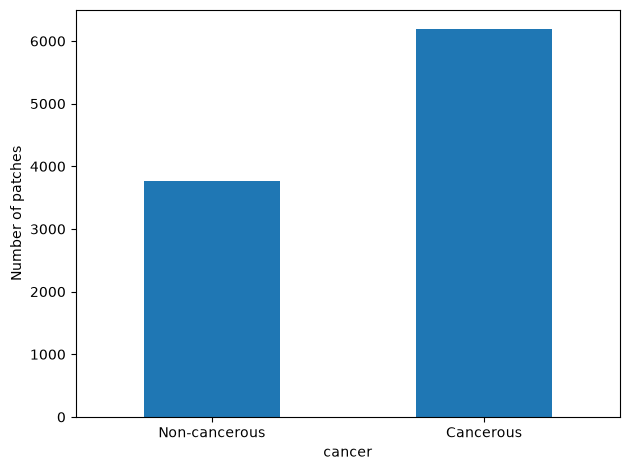

In [12]:
train_df["cancer"].value_counts().sort_index().rename(index={0: "Non-cancerous", 1: "Cancerous"}).plot.bar()
plt.ylabel("Number of patches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
image_paths = [path for path in IMAGE_DIR.rglob("*") if path.is_file()]
image_files = {path.name: path for path in image_paths}
if len(image_files) != len(image_paths):
    raise ValueError("Image filenames are duplicated across folders.")
for df in [train_df, test_df]:
    if not df["image_name"].isin(image_files).all():
        raise ValueError("Some labelled images are missing from the images folder.")
mask_paths = list(MASK_DIR.rglob("*.png"))
mask_files = {path.stem: path for path in mask_paths}
if len(mask_files) != len(mask_paths):
    raise ValueError("Mask filenames are duplicated across folders.")

### Image and annotation inspection



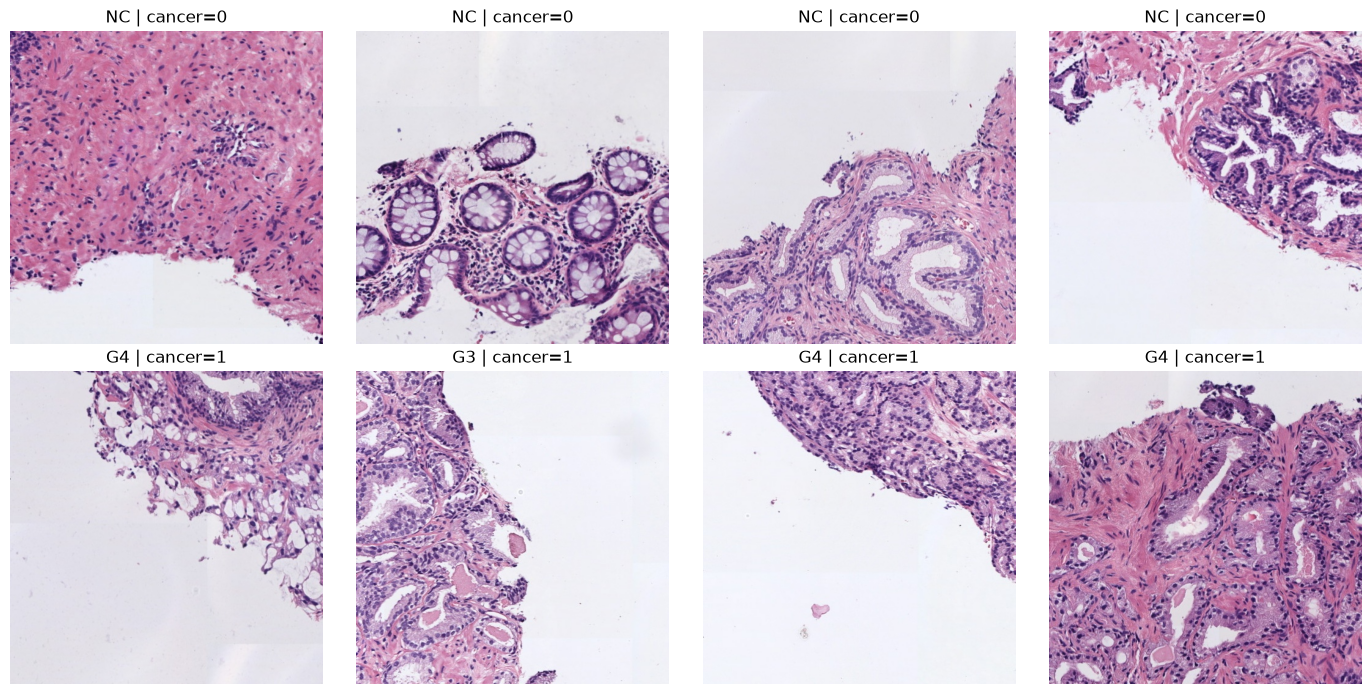

In [14]:
samples = pd.concat(
    [
        train_df.loc[train_df["cancer"] == 0].sample(4, random_state=RANDOM_STATE),
        train_df.loc[train_df["cancer"] == 1].sample(4, random_state=RANDOM_STATE),
    ]
)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    with Image.open(image_files[row["image_name"]]) as image:
        ax.imshow(image.convert("RGB"))

    grade = next(col for col in ["NC", "G3", "G4", "G5"] if row[col] == 1)
    ax.set_title(f"{grade} | cancer={row['cancer']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

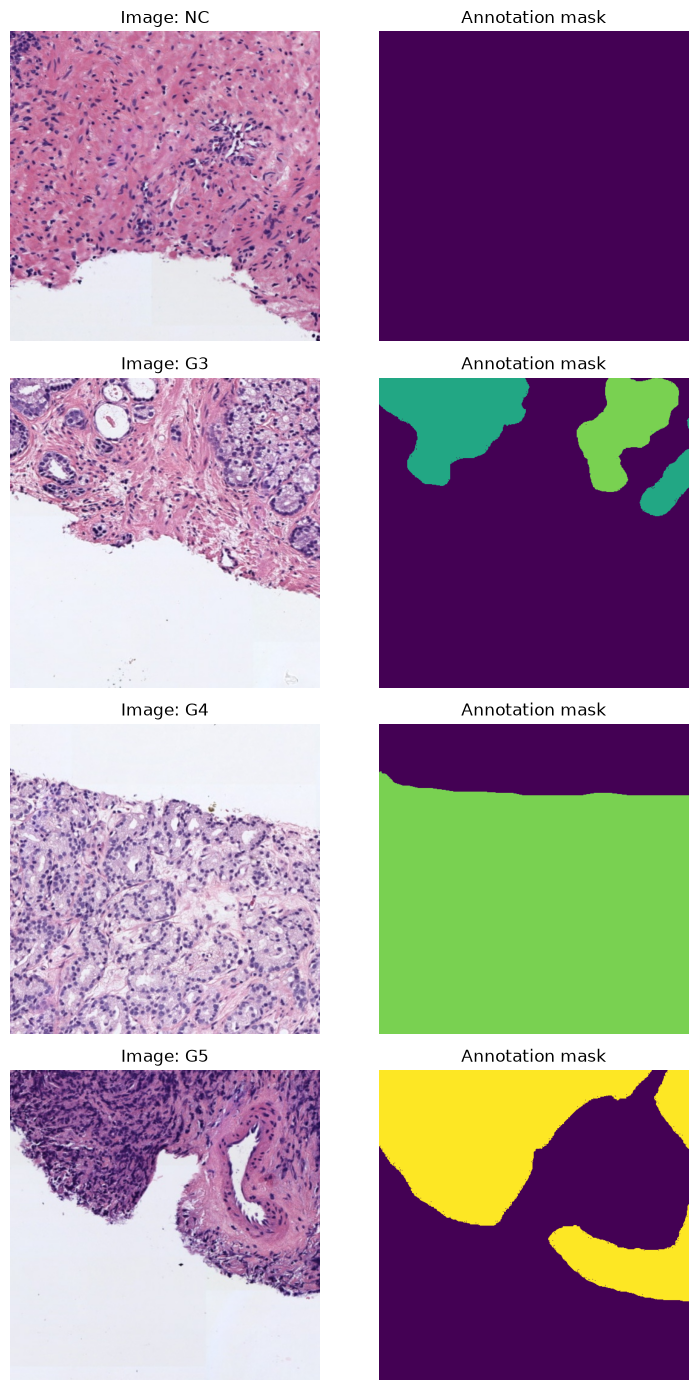

In [15]:
samples = pd.concat([
    train_df.loc[train_df[grade] == 1].sample(1, random_state=RANDOM_STATE)
    for grade in GRADE_COLUMNS
], ignore_index=True)
fig, axes = plt.subplots(4, 2, figsize=(8, 14))
for i, row in samples.iterrows():
    name = row["image_name"]
    grade = next(grade for grade in GRADE_COLUMNS if row[grade] == 1)
    with Image.open(image_files[name]) as image:
        axes[i, 0].imshow(image.convert("RGB"))
    with Image.open(mask_files[Path(name).stem]) as mask:
        axes[i, 1].imshow(np.asarray(mask), cmap="viridis", vmin=0, vmax=5)
    axes[i, 0].set_title(f"Image: {grade}")
    axes[i, 1].set_title("Annotation mask")
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()
plt.show()

### Image resizing and normalization

Load RGB images, resize to 224 × 224 and apply MobileNetV2 preprocessing. Images are processed in batches of 8, preserving their order.

In [16]:
def load_image(path, label):
    image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, tf.cast(label, tf.int32)

In [17]:
def make_dataset(df):
    paths = [str(image_files[name]) for name in df["image_name"]]
    labels = df["cancer"].to_numpy(dtype="int32")
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## CNN feature extraction

In [ ]:
cnn_feature_extractor = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
    pooling="avg",
)
cnn_feature_extractor.trainable = False

In [19]:
development_dataset = make_dataset(train_df)

In [20]:
X_development = cnn_feature_extractor.predict(development_dataset, verbose=1)

1245/1245 ━━━━━━━━━━━━━━━━━━━━ 586s 466ms/step


In [21]:
y_development = train_df["cancer"].to_numpy(dtype="int32")
X_development.shape

(9959, 1280)

## Training and test sets

In [22]:
feature_index = pd.Series(np.arange(len(train_df)), index=train_df["image_name"])

In [23]:
validation_folds = []
for fold_number in range(1, 5):
    fold_dir = DATA_DIR / "partition" / "Validation" / f"Val{fold_number}"
    fold_train_df = prepare_labels(pd.read_excel(fold_dir / "Train.xlsx"))
    fold_valid_df = prepare_labels(pd.read_excel(fold_dir / "Test.xlsx"))
    validation_folds.append((fold_train_df, fold_valid_df))

In [24]:
for fold_number, (fold_train_df, fold_valid_df) in enumerate(validation_folds, start=1):
    if set(fold_train_df["patient_id"]) & set(fold_valid_df["patient_id"]):
        raise ValueError(f"Fold {fold_number} contains shared patients.")
    if set(fold_train_df["image_name"]) & set(fold_valid_df["image_name"]):
        raise ValueError(f"Fold {fold_number} contains shared images.")
    fold_images = set(fold_train_df["image_name"]) | set(fold_valid_df["image_name"])
    if fold_images != set(train_df["image_name"]):
        raise ValueError(f"Fold {fold_number} does not match the development set.")

In [25]:
cv_splits = []
for fold_train_df, fold_valid_df in validation_folds:
    train_indices = feature_index.loc[fold_train_df["image_name"]].to_numpy()
    valid_indices = feature_index.loc[fold_valid_df["image_name"]].to_numpy()
    cv_splits.append((train_indices, valid_indices))

In [26]:
for fold_number, ((fold_train_df, fold_valid_df), (train_indices, valid_indices)) in enumerate(zip(validation_folds, cv_splits), start=1):
    if not np.array_equal(fold_train_df["cancer"].to_numpy(), y_development[train_indices]):
        raise ValueError(f"Fold {fold_number} training labels do not match the features.")
    if not np.array_equal(fold_valid_df["cancer"].to_numpy(), y_development[valid_indices]):
        raise ValueError(f"Fold {fold_number} validation labels do not match the features.")

In [27]:
validation_coverage = np.zeros(len(train_df), dtype=int)
for train_indices, valid_indices in cv_splits:
    validation_coverage[valid_indices] += 1
if not np.all(validation_coverage == 1):
    raise ValueError("Every development patch must appear in validation exactly once.")

## Model training

Compare Linear SVM, Random Forest and KNN

### Linear SVM

In [28]:
svm_model = Pipeline([('scaler', StandardScaler()), ('classifier', LinearSVC(C=1.0, class_weight='balanced', max_iter=10000, random_state=RANDOM_STATE))])

In [29]:
svm_validation_results = []
for fold_number, (train_indices, valid_indices) in enumerate(cv_splits, start=1):
    model = clone(svm_model)
    model.fit(X_development[train_indices], y_development[train_indices])
    predictions = model.predict(X_development[valid_indices])
    svm_validation_results.append({
        "Fold": fold_number,
        "Model": "Linear SVM",
        "Accuracy": accuracy_score(y_development[valid_indices], predictions),
        "Recall": recall_score(y_development[valid_indices], predictions, zero_division=0),
        "Precision": precision_score(y_development[valid_indices], predictions, zero_division=0),
    })

In [30]:
svm_validation_df = pd.DataFrame(svm_validation_results)
svm_validation_df.round(4)

,Fold,Model,Accuracy,Recall,Precision
0,1,Linear SVM,0.7897,0.8163,0.8845
1,2,Linear SVM,0.7922,0.9165,0.8014
2,3,Linear SVM,0.7440,0.7929,0.8048
3,4,Linear SVM,0.6365,0.8768,0.5970


### Random Forest

In [31]:
rf_model = RandomForestClassifier(n_estimators=300, max_features='sqrt', min_samples_leaf=2, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)

In [32]:
rf_validation_results = []
for fold_number, (train_indices, valid_indices) in enumerate(cv_splits, start=1):
    model = clone(rf_model)
    model.fit(X_development[train_indices], y_development[train_indices])
    predictions = model.predict(X_development[valid_indices])
    rf_validation_results.append({
        "Fold": fold_number,
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_development[valid_indices], predictions),
        "Recall": recall_score(y_development[valid_indices], predictions, zero_division=0),
        "Precision": precision_score(y_development[valid_indices], predictions, zero_division=0),
    })

In [33]:
rf_validation_df = pd.DataFrame(rf_validation_results)
rf_validation_df.round(4)

,Fold,Model,Accuracy,Recall,Precision
0,1,Random Forest,0.8130,0.8912,0.8565
1,2,Random Forest,0.8246,0.9213,0.8339
2,3,Random Forest,0.7646,0.8468,0.7982
3,4,Random Forest,0.6319,0.9619,0.5838


### KNN

In [34]:
knn_model = Pipeline([('scaler', StandardScaler()), ('classifier', KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean', algorithm='brute', n_jobs=-1))])

In [35]:
knn_validation_results = []
for fold_number, (train_indices, valid_indices) in enumerate(cv_splits, start=1):
    model = clone(knn_model)
    model.fit(X_development[train_indices], y_development[train_indices])
    predictions = model.predict(X_development[valid_indices])
    knn_validation_results.append({
        "Fold": fold_number,
        "Model": "KNN",
        "Accuracy": accuracy_score(y_development[valid_indices], predictions),
        "Recall": recall_score(y_development[valid_indices], predictions, zero_division=0),
        "Precision": precision_score(y_development[valid_indices], predictions, zero_division=0),
    })

In [36]:
knn_validation_df = pd.DataFrame(knn_validation_results)
knn_validation_df.round(4)

,Fold,Model,Accuracy,Recall,Precision
0,1,KNN,0.7728,0.8779,0.8210
1,2,KNN,0.7793,0.9179,0.7874
2,3,KNN,0.7407,0.8634,0.7631
3,4,KNN,0.6428,0.9339,0.5947


### Baseline comparison

In [37]:
validation_results_df = pd.concat([svm_validation_df, rf_validation_df, knn_validation_df], ignore_index=True)

In [38]:
validation_results_df.groupby("Model")[["Accuracy", "Recall", "Precision"]].mean().round(4)

,Accuracy,Recall,Precision
Model,,,
KNN,0.7339,0.8983,0.7415
Linear SVM,0.7406,0.8506,0.7719
Random Forest,0.7585,0.9053,0.7681


### Random Forest optimization

Random Forest was selected from the earlier baseline comparison. 

In [39]:
rf_search_model = RandomForestClassifier(
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

In [40]:
rf_parameter_distributions = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 20, 30],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_samples": [0.7, 0.85, None],
}

In [41]:
scoring_metrics = {
    "accuracy": "accuracy",
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
}

In [42]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_search_model,
    param_distributions=rf_parameter_distributions,
    n_iter=10,
    scoring=scoring_metrics,
    refit="recall",
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

In [43]:
rf_random_search.fit(X_development, y_development)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 20, ...], 'max_features': ['sqrt', 'log2'], 'max_samples': [0.7, 0.85, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'precision': make_scorer(p...ro_division=0), 'recall': make_scorer(r...ro_division=0)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :re

In [44]:
rf_search_results = pd.DataFrame(rf_random_search.cv_results_)
rf_search_results[["rank_test_recall", "mean_test_accuracy", "mean_test_recall", "mean_test_precision", "params"]].sort_values("rank_test_recall").round(4)

,rank_test_recall,mean_test_accuracy,mean_test_recall,mean_test_precision,params
6,1,0.7551,0.9136,0.7607,"{'n_estimators': 300, 'min_samples_split': 5, ..."
5,2,0.7548,0.9116,0.7612,"{'n_estimators': 200, 'min_samples_split': 10,..."
9,3,0.7607,0.9070,0.7691,"{'n_estimators': 300, 'min_samples_split': 5, ..."
7,4,0.7573,0.9063,0.7663,"{'n_estimators': 200, 'min_samples_split': 2, ..."
4,5,0.7592,0.9053,0.7678,"{'n_estimators': 300, 'min_samples_split': 5, ..."
3,6,0.7613,0.9019,0.7711,"{'n_estimators': 300, 'min_samples_split': 10,..."
0,7,0.7604,0.8993,0.7714,"{'n_estimators': 200, 'min_samples_split': 10,..."
8,8,0.7670,0.8952,0.7797,"{'n_estimators': 400, 'min_samples_split': 5, ..."
2,9,0.7679,0.8939,0.7809,"{'n_estimators': 400, 'min_samples_split': 10,..."
1,10,0.7650,0.8938,0.7789,"{'n_estimators': 300, 'min_samples_split': 2, ..."


In [45]:
rf_random_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_samples': 0.85,
 'max_features': 'sqrt',
 'max_depth': 20}

### Trained model

In [46]:
final_rf_model = rf_random_search.best_estimator_

## Evaluation

Evaluate the selected model on the final test patches.

In [47]:
final_test_dataset = make_dataset(test_df)

In [48]:
X_final_test = cnn_feature_extractor.predict(final_test_dataset, verbose=1)

266/266 ━━━━━━━━━━━━━━━━━━━━ 136s 425ms/step


In [49]:
y_final_test = test_df["cancer"].to_numpy(dtype="int32")

In [50]:
final_test_predictions = final_rf_model.predict(X_final_test)

In [51]:
final_test_results = pd.DataFrame({
    "Metric": ["Accuracy", "Recall", "Precision"],
    "Score": [
        accuracy_score(y_final_test, final_test_predictions),
        recall_score(y_final_test, final_test_predictions, zero_division=0),
        precision_score(y_final_test, final_test_predictions, zero_division=0),
    ],
})
final_test_results.round(4)

,Metric,Score
0,Accuracy,0.8101
1,Recall,0.8775
2,Precision,0.8539


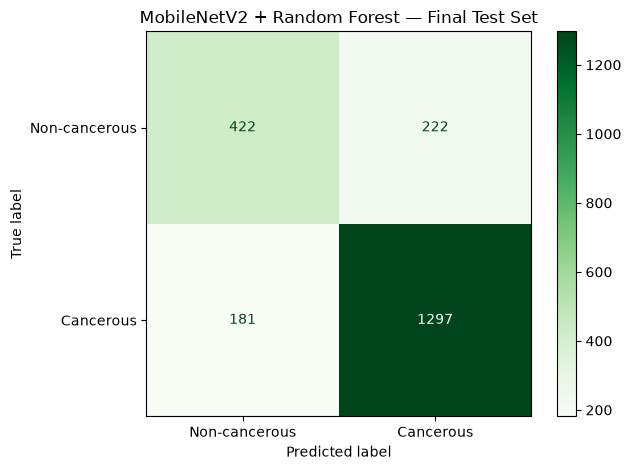

In [52]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
chart = ConfusionMatrixDisplay.from_predictions(
    y_final_test,
    final_test_predictions,
    labels=[0, 1],
    display_labels=CLASS_NAMES,
    cmap="Greens",
    values_format="d",
)
plt.title("MobileNetV2 + Random Forest — Final Test Set")
plt.tight_layout()
plt.savefig(MODEL_DIR / "final_test_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Save the model

In [ ]:
joblib.dump(final_rf_model, MODEL_DIR / "optimized_random_forest.joblib")